# 🎓 Real-Time Sentiment Analysis — Model Training
**Course:** High Performance Data Processing (SECP3133)  
**Project:** Real-Time Sentiment Analysis using Apache Kafka and Apache Spark

---

## Dataset Info
- **Source:** YouTube comments (Malaysian dataset, labelled via XLM-RoBERTa)
- **Size:** 3,349 rows
- **Language:** Mixed English + Malay (pre-cleaned, stemmed)
- **Labels:** `negative` (61.5%) · `neutral` (26.6%) · `positive` (11.9%)

## Pipeline
| Step | Description |
|------|-------------|
| 1 | Data Loading & Exploration |
| 2 | TF-IDF Vectorisation |
| 3 | Stratified Train / Val / Test Split (70 / 10 / 20) |
| 4 | Model Training — Naive Bayes · Logistic Regression · XLM-RoBERTa |
| 5 | Evaluation — Accuracy · Precision · Recall · F1 · Confusion Matrix |
| 6 | Sentiment Distribution Analysis |
| 7 | Visualisations |
| 8 | Best Model Selection |
| 9 | Model Saving (Spark-ready) |
| 10 | `predict_sentiment()` — Spark UDF |
| 11 | CSV Exports |


## 0 · Environment Setup & Imports

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'transformers', 'torch', '--quiet', '--disable-pip-version-check'],
               check=False)

import os, warnings, random, re
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from transformers import (AutoTokenizer,
                           AutoModelForSequenceClassification,
                           Trainer, TrainingArguments, EarlyStoppingCallback)
import torch
from torch.utils.data import Dataset
import joblib

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("✅ All libraries loaded.")
print(f"   Device       : {DEVICE} {'🚀 GPU ready' if str(DEVICE)!='cpu' else '⚠️  CPU — switch to T4 GPU for XLM-RoBERTa'}")
print(f"   Transformers : {__import__('transformers').__version__}")
print(f"   PyTorch      : {torch.__version__}")
print(f"   Scikit-learn : {__import__('sklearn').__version__}")


✅ All libraries loaded.
   Device       : cuda 🚀 GPU ready
   Transformers : 5.10.2
   PyTorch      : 2.11.0+cu128
   Scikit-learn : 1.6.1


## 1 · Data Loading

Dataset: Malaysian YouTube comments labelled by XLM-RoBERTa (multilingual model).
Only `cleaned_text` and `sentiment` are used for model training.


In [ ]:
CSV_PATH = 'youtube_comments_cleaned_roberta.csv'

df = pd.read_csv(CSV_PATH)
df = df[['cleaned_text', 'sentiment']].copy()
df.dropna(subset=['cleaned_text', 'sentiment'], inplace=True)
df = df[df['cleaned_text'].str.strip() != '']
df.reset_index(drop=True, inplace=True)

print(f"Dataset shape : {df.shape}")
print(f"Unique labels : {sorted(df['sentiment'].unique())}")
df.head(10)


Dataset shape : (3349, 2)
Unique labels : ['negative', 'neutral', 'positive']


,cleaned_text,sentiment
0,say subsidi destruct green technolog hail natu...,positive
1,malaysia realiti far beyong nightmar that,negative
2,sinc low pay sohai,neutral
3,diesel price jump normalis,neutral
4,alot busi seiz golden opportun increas price b...,positive
5,per say help give dolar definit noth big impac...,neutral
6,telo anwar turun sen bercukurlah,negative
7,afifah seem happi live malaysia,positive
8,alamak kena pakai kereta lembu sekejap hari,positive
9,fake news,negative


📊 Class Distribution:
           Count  Percentage
sentiment                   
negative    2060       61.51
neutral      890       26.58
positive     399       11.91


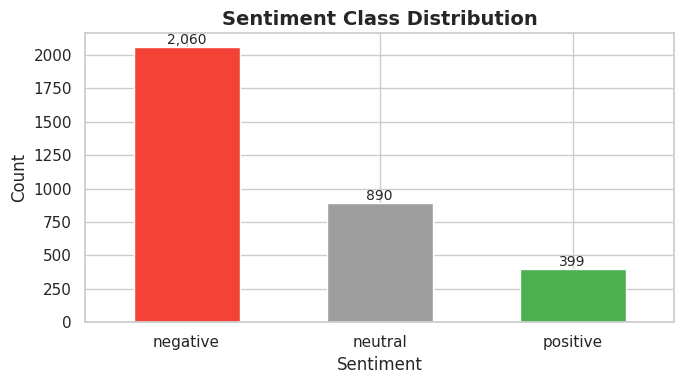


📏 Text length stats (words):
count    3349.0
mean       14.4
std        17.2
min         1.0
25%         5.0
50%         9.0
75%        17.0
max       335.0


In [ ]:
dist     = df['sentiment'].value_counts()
dist_pct = df['sentiment'].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({'Count': dist, 'Percentage': dist_pct.round(2)})
print("📊 Class Distribution:")
print(dist_df.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#F44336', '#9E9E9E', '#4CAF50']
dist.plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.55)
ax.set_title('Sentiment Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(dist.index, rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

lengths = df['cleaned_text'].apply(lambda x: len(str(x).split()))
print(f"\n📏 Text length stats (words):")
print(lengths.describe().round(1).to_string())


## 2 · Text Preprocessing — TF-IDF Vectorisation

The text is already cleaned and stemmed by the data engineering team.
TF-IDF converts text to a numerical matrix for Naive Bayes and Logistic Regression.
XLM-RoBERTa uses its own tokeniser — TF-IDF is **not** used for XLM-RoBERTa.

| Parameter | Value | Reason |
|-----------|-------|--------|
| `max_features` | 15,000 | Smaller vocab suits stemmed short texts |
| `ngram_range` | (1, 2) | Unigrams + bigrams |
| `sublinear_tf` | True | Log-scale dampens frequent terms |
| `min_df` | 2 | Drop words appearing only once |


In [ ]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])
LABEL_NAMES = list(le.classes_)   # ['negative', 'neutral', 'positive']
NUM_CLASSES  = len(LABEL_NAMES)
print(f"Label mapping : {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"Classes       : {LABEL_NAMES}")

# Smaller vocab (15k) — dataset is only 3,349 rows, stemmed text
tfidf = TfidfVectorizer(max_features=15_000, ngram_range=(1, 2),
                         sublinear_tf=True, min_df=2, strip_accents='unicode')
X_tfidf = tfidf.fit_transform(df['cleaned_text'])
y        = df['label'].values
print(f"\nTF-IDF matrix shape : {X_tfidf.shape}")


Label mapping : {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Classes       : ['negative', 'neutral', 'positive']

TF-IDF matrix shape : (3349, 7531)


## 3 · Train / Validation / Test Split

| Split | Ratio | Samples (approx) |
|-------|-------|-----------------|
| Train | 70 % | ~2,344 |
| Validation | 10 % | ~335 |
| Test | 20 % | ~670 |

Stratified to preserve negative/neutral/positive ratio in every split.


In [ ]:
# TF-IDF splits (NB + LR)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_tfidf, y, test_size=0.20, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=SEED, stratify=y_temp)

total = len(y)
print("📐 Split Summary")
print(f"  Total      : {total:,}")
print(f"  Train      : {len(y_train):,}  ({len(y_train)/total*100:.1f}%)")
print(f"  Validation : {len(y_val):,}   ({len(y_val)/total*100:.1f}%)")
print(f"  Test       : {len(y_test):,}   ({len(y_test)/total*100:.1f}%)")

# Class weights — negative (61%) is majority, positive (12%) is minority
cw_arr  = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(cw_arr))
print(f"\n⚖️  Class weights:")
for i, w in cw_dict.items():
    print(f"   {LABEL_NAMES[i]:<12} → {w:.4f}")


📐 Split Summary
  Total      : 3,349
  Train      : 2,344  (70.0%)
  Validation : 335   (10.0%)
  Test       : 670   (20.0%)

⚖️  Class weights:
   negative     → 0.5418
   neutral      → 1.2541
   positive     → 2.8005


## 4 · Model Training

| # | Model | Type | Handles Imbalance Via |
|---|-------|------|-----------------------|
| 1 | Multinomial Naive Bayes | Classical probabilistic | Class prior |
| 2 | Logistic Regression | Classical linear | `class_weight='balanced'` |
| 3 | XLM-RoBERTa | Pretrained Transformer | Weighted cross-entropy loss |



### 4.1 · Model 1 — Multinomial Naive Bayes

Probabilistic baseline. `alpha=0.1` applies Laplace smoothing. Fast to train even on small datasets.

In [ ]:
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("✅ Naive Bayes trained.")
print(classification_report(y_test, y_pred_nb, target_names=LABEL_NAMES))


✅ Naive Bayes trained.
              precision    recall  f1-score   support

    negative       0.68      0.86      0.76       412
     neutral       0.53      0.38      0.44       178
    positive       0.37      0.09      0.14        80

    accuracy                           0.64       670
   macro avg       0.52      0.44      0.45       670
weighted avg       0.60      0.64      0.60       670



### 4.2 · Model 2 — Logistic Regression

`class_weight='balanced'` adjusts for the 61% negative dominance. `C=0.5` adds stronger regularisation — important for small datasets to prevent overfitting.

In [ ]:
lr_model = LogisticRegression(
    C=0.5,              # stronger regularisation for small dataset
    max_iter=1000, solver='saga',
    multi_class='multinomial', class_weight='balanced',
    random_state=SEED, n_jobs=-1)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("✅ Logistic Regression trained.")
print(classification_report(y_test, y_pred_lr, target_names=LABEL_NAMES))


✅ Logistic Regression trained.
              precision    recall  f1-score   support

    negative       0.75      0.75      0.75       412
     neutral       0.49      0.53      0.51       178
    positive       0.36      0.30      0.33        80

    accuracy                           0.64       670
   macro avg       0.53      0.53      0.53       670
weighted avg       0.64      0.64      0.64       670



### 4.3 · Model 3 — XLM-RoBERTa (HuggingFace Transformers)

**XLM-RoBERTa** is a multilingual transformer trained on 2.5 TB of text across **100 languages including Malay**.
It is the same model family used to label this dataset — fine-tuning it on our data
teaches it to specialise in Malaysian YouTube comments.

**Fine-tuning strategy:**
```
[CLS] token₁ token₂ ... tokenₙ [SEP]
           ↓
  XLM-RoBERTa (12 transformer layers, multilingual)
           ↓
  Pooled [CLS] embedding (768-dim)
           ↓
  Dropout → Linear(768 → 3) → Softmax
```
Checkpoint: `xlm-roberta-base` | LR: `2e-5` | Epochs: up to 8 with early stopping


In [ ]:
MODEL_NAME  = 'xlm-roberta-base'
MAX_LEN     = 64    # longer than before — XLM-RoBERTa handles Malay tokens better with more context
BERT_BATCH  = 16    # small dataset (3,349 rows)
BERT_EPOCHS = 8     # more epochs; EarlyStopping prevents overfit
LR          = 2e-5  # standard fine-tuning LR

print(f"🤖 Model      : {MODEL_NAME}")
print(f"📏 MAX_LEN    : {MAX_LEN}")
print(f"🔢 Batch size : {BERT_BATCH}")
print(f"💻 Device     : {DEVICE}")

# Raw text splits for XLM-RoBERTa
texts  = df['cleaned_text'].astype(str).values
labels = df['label'].values

X_b_temp, X_b_test, y_b_temp, y_b_test = train_test_split(
    texts, labels, test_size=0.20, random_state=SEED, stratify=labels)
X_b_train, X_b_val, y_b_train, y_b_val = train_test_split(
    X_b_temp, y_b_temp, test_size=0.125, random_state=SEED, stratify=y_b_temp)

print(f"\nSplits — Train: {len(y_b_train):,} | Val: {len(y_b_val):,} | Test: {len(y_b_test):,}")

# Class weight tensor
cw_bert   = compute_class_weight('balanced', classes=np.unique(y_b_train), y=y_b_train)
cw_tensor = torch.tensor(cw_bert, dtype=torch.float).to(DEVICE)
print("\n⚖️  Class weights:")
for i, w in enumerate(cw_bert):
    print(f"   {LABEL_NAMES[i]:<12} → {w:.4f}")

# Load XLM-RoBERTa tokeniser via AutoTokenizer
bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"\n✅ Tokeniser loaded: {MODEL_NAME}")


🤖 Model      : xlm-roberta-base
📏 MAX_LEN    : 64
🔢 Batch size : 16
💻 Device     : cuda

Splits — Train: 2,344 | Val: 335 | Test: 670

⚖️  Class weights:
   negative     → 0.5418
   neutral      → 1.2541
   positive     → 2.8005


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]


✅ Tokeniser loaded: xlm-roberta-base


In [ ]:
class SentimentDataset(Dataset):
    """
    PyTorch Dataset wrapper for XLM-RoBERTa.
    Tokenises all texts upfront and stores as tensors.
    Each item returns input_ids, attention_mask, and label.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding='max_length',
            max_length=max_len, return_tensors='pt')
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {'input_ids'     : self.encodings['input_ids'][idx],
                'attention_mask': self.encodings['attention_mask'][idx],
                'labels'        : self.labels[idx]}

train_dataset = SentimentDataset(X_b_train, y_b_train, bert_tokenizer, MAX_LEN)
val_dataset   = SentimentDataset(X_b_val,   y_b_val,   bert_tokenizer, MAX_LEN)
test_dataset  = SentimentDataset(X_b_test,  y_b_test,  bert_tokenizer, MAX_LEN)
print(f"✅ Datasets ready:")
print(f"   Train : {len(train_dataset):,} | Val : {len(val_dataset):,} | Test : {len(test_dataset):,}")


✅ Datasets ready:
   Train : 2,344 | Val : 335 | Test : 670


In [ ]:
# Load XLM-RoBERTa with 3-class classification head via AutoModel
xlm_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_CLASSES,
    id2label={i: l for i, l in enumerate(LABEL_NAMES)},
    label2id={l: i for i, l in enumerate(LABEL_NAMES)})
xlm_model.to(DEVICE)
print(f"✅ XLM-RoBERTa loaded — {sum(p.numel() for p in xlm_model.parameters()):,} parameters")
print("   (MISSING/UNEXPECTED warnings above are normal — classification head is newly initialised)")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss    = torch.nn.CrossEntropyLoss(weight=cw_tensor)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_bert_metrics(eval_pred):
    preds  = np.argmax(eval_pred.predictions, axis=1)
    labels = eval_pred.label_ids
    return {
        'accuracy' : round(accuracy_score(labels, preds), 4),
        'f1'       : round(f1_score(labels, preds, average='weighted', zero_division=0), 4),
        'precision': round(precision_score(labels, preds, average='weighted', zero_division=0), 4),
        'recall'   : round(recall_score(labels, preds, average='weighted', zero_division=0), 4),
    }


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ XLM-RoBERTa loaded — 278,045,955 parameters
   (MISSING/UNEXPECTED warnings above are normal — classification head is newly initialised)


In [ ]:
training_args = TrainingArguments(
    output_dir                  = './xlm_checkpoints',
    num_train_epochs            = BERT_EPOCHS,
    per_device_train_batch_size = BERT_BATCH,
    per_device_eval_batch_size  = BERT_BATCH,
    learning_rate               = LR,
    weight_decay                = 0.01,
    warmup_steps                = 50,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    greater_is_better           = True,
    logging_steps               = 20,
    seed                        = SEED,
    report_to                   = 'none',
    fp16                        = torch.cuda.is_available(),
)

trainer = WeightedTrainer(
    model=xlm_model, args=training_args,
    train_dataset=train_dataset, eval_dataset=val_dataset,
    compute_metrics=compute_bert_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("🚀 Starting XLM-RoBERTa fine-tuning...")
trainer.train()
print("\n✅ XLM-RoBERTa fine-tuning complete.")


🚀 Starting XLM-RoBERTa fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.106529,1.084965,0.549300,0.477400,0.423300,0.549300
2,1.021447,0.987538,0.603000,0.603500,0.646300,0.603000
3,0.959573,0.939588,0.683600,0.666800,0.716700,0.683600
4,0.938801,0.846063,0.638800,0.655300,0.697600,0.638800
5,0.757019,0.853393,0.662700,0.673400,0.701500,0.662700
6,0.630984,0.934445,0.683600,0.688700,0.696800,0.683600
7,0.504616,0.990472,0.701500,0.703000,0.704700,0.701500
8,0.524200,1.012172,0.701500,0.704700,0.710300,0.701500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ XLM-RoBERTa fine-tuning complete.


In [ ]:
# Predictions on test set
xlm_raw     = trainer.predict(test_dataset)
y_pred_bert = np.argmax(xlm_raw.predictions, axis=1)
y_true_bert = np.array(y_b_test)

# Label breakdown — all 3 classes should appear
print("🔍 XLM-RoBERTa — Predicted Label Breakdown:")
for u, c in zip(*np.unique(y_pred_bert, return_counts=True)):
    print(f"   {LABEL_NAMES[u]:<12}: {c:>4}  ({c/len(y_pred_bert)*100:.1f}%)")

# Manual probe — English + Malay
print("\n🧪 Manual Probe:")
def xlm_predict_single(text):
    enc = bert_tokenizer(text, truncation=True, padding='max_length',
                         max_length=MAX_LEN, return_tensors='pt')
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        logits = xlm_model(**enc).logits
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    return LABEL_NAMES[int(np.argmax(probs))], float(probs.max()*100)

probe = [
    ("I absolutely love this video, it is amazing!",  "positive"),
    ("The video was okay, nothing special.",           "neutral"),
    ("Terrible content, I hated every second.",        "negative"),
    ("harga naik rakyat susah kerajaan tak kisah",     "negative"),
    ("bagus kerajaan buat kerja yang baik",            "positive"),
    ("biasa je tak ada yang menarik",                  "neutral"),
]
print(f"  {'Text':<48} | Expected   | Predicted  | Conf")
print("  " + "-"*85)
for txt, exp in probe:
    pred, conf = xlm_predict_single(txt)
    print(f"  {txt[:46]:<48} | {exp:<10} | {pred:<10} | {conf:.1f}% {'✅' if pred==exp else '❌'}")

print("\n📋 Full Classification Report:")
print(classification_report(y_true_bert, y_pred_bert, target_names=LABEL_NAMES))


🔍 XLM-RoBERTa — Predicted Label Breakdown:
   negative    :  422  (63.0%)
   neutral     :  176  (26.3%)
   positive    :   72  (10.7%)

🧪 Manual Probe:
  Text                                             | Expected   | Predicted  | Conf
  -------------------------------------------------------------------------------------
  I absolutely love this video, it is amazing!     | positive   | positive   | 95.9% ✅
  The video was okay, nothing special.             | neutral    | positive   | 96.1% ❌
  Terrible content, I hated every second.          | negative   | negative   | 90.5% ✅
  harga naik rakyat susah kerajaan tak kisah       | negative   | negative   | 53.9% ✅
  bagus kerajaan buat kerja yang baik              | positive   | positive   | 97.6% ✅
  biasa je tak ada yang menarik                    | neutral    | positive   | 53.3% ❌

📋 Full Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.83      0.82       412
     neutral 

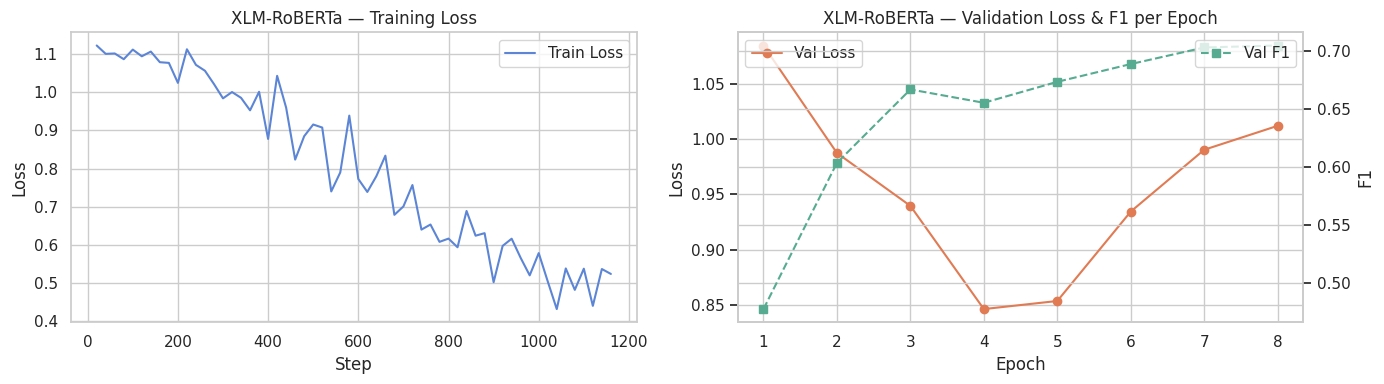

In [ ]:
logs       = trainer.state.log_history
train_logs = [x for x in logs if 'loss' in x and 'eval_loss' not in x]
eval_logs  = [x for x in logs if 'eval_loss' in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
if train_logs:
    axes[0].plot([x['step'] for x in train_logs],
                 [x['loss'] for x in train_logs], color='#5C85D6', label='Train Loss')
    axes[0].set_title('XLM-RoBERTa — Training Loss')
    axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss'); axes[0].legend()
if eval_logs:
    epochs = [x['epoch'] for x in eval_logs]
    axes[1].plot(epochs, [x['eval_loss'] for x in eval_logs],
                 color='#E07B54', marker='o', label='Val Loss')
    ax2 = axes[1].twinx()
    ax2.plot(epochs, [x.get('eval_f1', 0) for x in eval_logs],
             color='#56AB91', marker='s', linestyle='--', label='Val F1')
    axes[1].set_title('XLM-RoBERTa — Validation Loss & F1 per Epoch')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); ax2.set_ylabel('F1')
    axes[1].legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('xlm_roberta_training_curves.png', dpi=150)
plt.show()


## 5 · Model Evaluation & Comparison

In [ ]:
def compute_metrics(y_true, y_pred, model_name):
    return {
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    }

results = [
    compute_metrics(y_test,      y_pred_nb,   'Naive Bayes'),
    compute_metrics(y_test,      y_pred_lr,   'Logistic Regression'),
    compute_metrics(y_true_bert, y_pred_bert, 'XLM-RoBERTa'),
]
comparison_df = pd.DataFrame(results).set_index('Model')
print("📊 Model Comparison Table")
print(comparison_df.to_string())
comparison_df.to_csv('model_comparison.csv')
print("\n💾 Saved → model_comparison.csv")


📊 Model Comparison Table
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Naive Bayes            0.6388     0.5996  0.6388    0.5987
Logistic Regression    0.6373     0.6350  0.6373    0.6357
XLM-RoBERTa            0.7403     0.7365  0.7403    0.7381

💾 Saved → model_comparison.csv


### 5.1 · Confusion Matrices

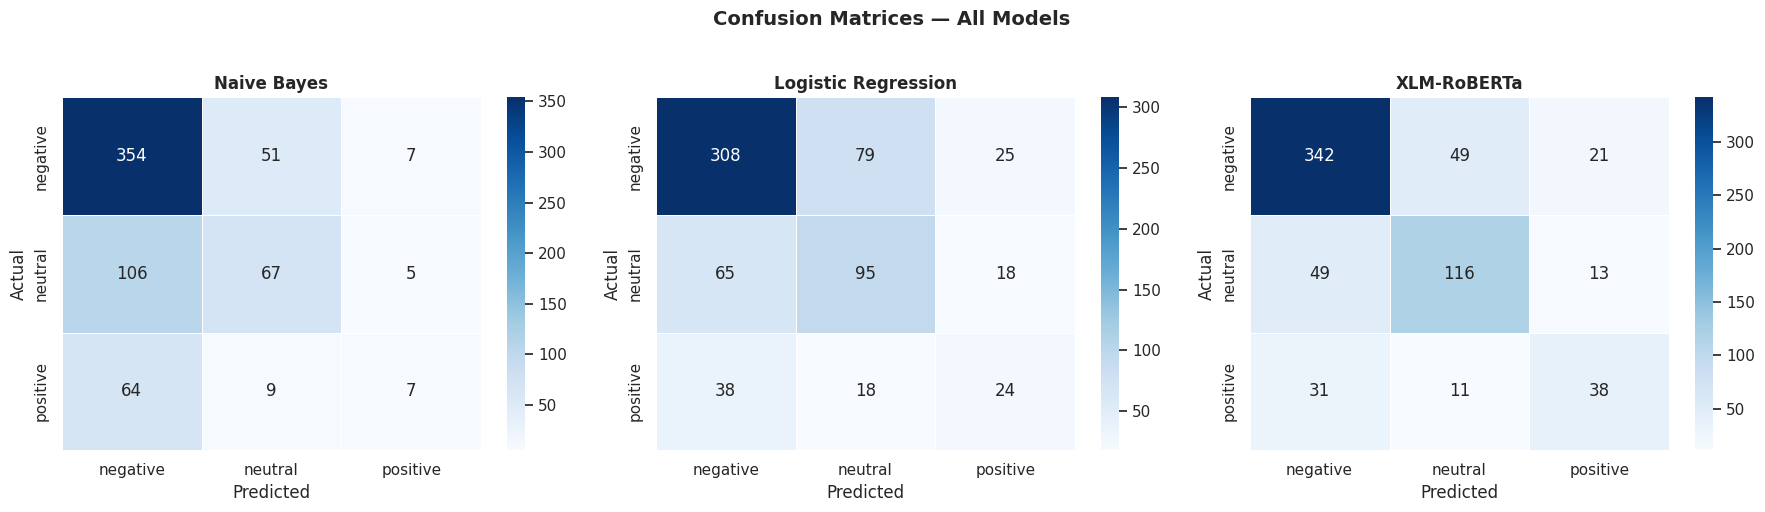

In [ ]:
def plot_confusion(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_confusion(y_test,      y_pred_nb,   'Naive Bayes',         axes[0])
plot_confusion(y_test,      y_pred_lr,   'Logistic Regression', axes[1])
plot_confusion(y_true_bert, y_pred_bert, 'XLM-RoBERTa',          axes[2])
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 6 · Sentiment Distribution Analysis

In [ ]:
def sentiment_distribution(y_pred, label_names, model_name):
    total  = len(y_pred)
    counts = {i: 0 for i in range(len(label_names))}
    for p in y_pred: counts[int(p)] += 1
    row = {'Model': model_name}
    for idx, lbl in enumerate(label_names):
        row[f'{lbl.capitalize()} %'] = round(counts[idx] / total * 100, 2)
    return row

dist_rows = [
    sentiment_distribution(y_pred_nb,   LABEL_NAMES, 'Naive Bayes'),
    sentiment_distribution(y_pred_lr,   LABEL_NAMES, 'Logistic Regression'),
    sentiment_distribution(y_pred_bert, LABEL_NAMES, 'XLM-RoBERTa'),
]
sent_dist_df = pd.DataFrame(dist_rows).set_index('Model')
print("📊 Predicted Sentiment Distribution (%) per Model")
print(sent_dist_df.to_string())
sent_dist_df.to_csv('sentiment_distribution.csv')
print("\n💾 Saved → sentiment_distribution.csv")


📊 Predicted Sentiment Distribution (%) per Model
                     Negative %  Neutral %  Positive %
Model                                                 
Naive Bayes               78.21      18.96        2.84
Logistic Regression       61.34      28.66       10.00
XLM-RoBERTa               62.99      26.27       10.75

💾 Saved → sentiment_distribution.csv


## 7 · Visualisations

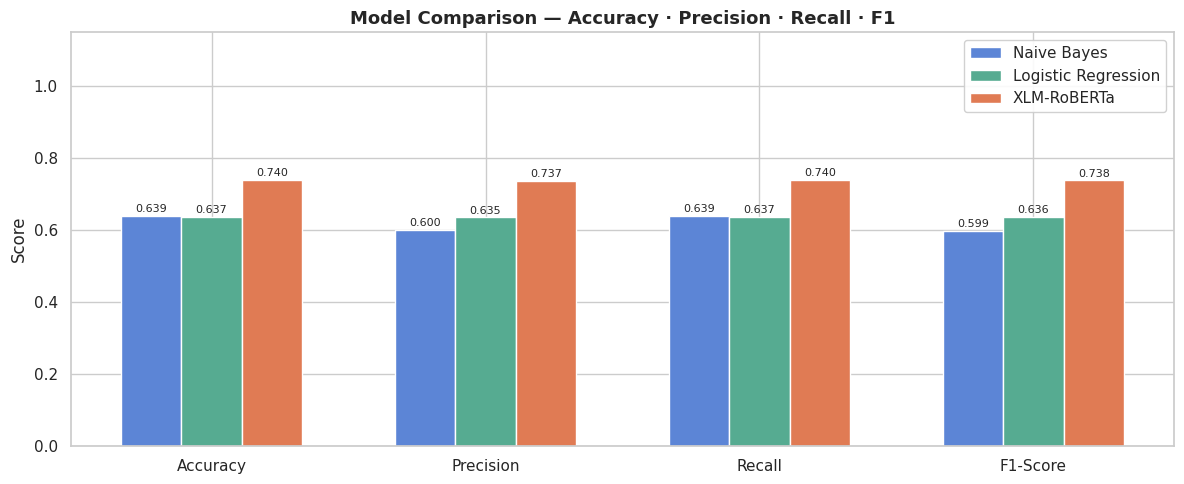

In [ ]:
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = comparison_df.index.tolist()
colors_bar  = ['#5C85D6', '#56AB91', '#E07B54']
x, width    = np.arange(len(metrics)), 0.22

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model, color) in enumerate(zip(model_names, colors_bar)):
    vals = [comparison_df.loc[model, m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=model, color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax.set_ylim(0, 1.15)
ax.set_xticks(x + width); ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy · Precision · Recall · F1',
             fontsize=13, fontweight='bold')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150)
plt.show()


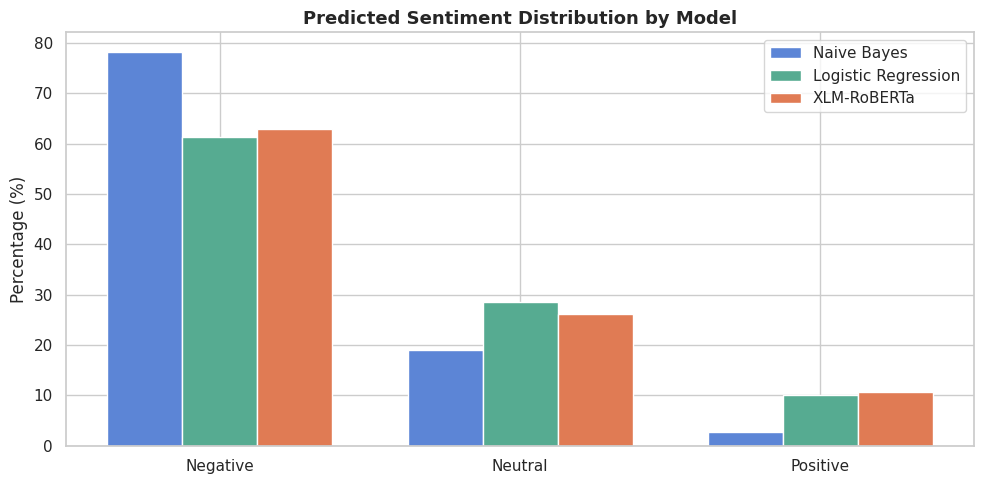

In [ ]:
pct_cols = [c for c in sent_dist_df.columns if '%' in c]
x2, bw   = np.arange(len(pct_cols)), 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (model, color) in enumerate(zip(model_names, colors_bar)):
    ax.bar(x2 + i*bw, sent_dist_df.loc[model, pct_cols].values,
           bw, label=model, color=color, edgecolor='white')
ax.set_xticks(x2 + bw)
ax.set_xticklabels([c.replace(' %','') for c in pct_cols], fontsize=11)
ax.set_ylabel('Percentage (%)')
ax.set_title('Predicted Sentiment Distribution by Model', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('sentiment_distribution_chart.png', dpi=150)
plt.show()


## 8 · Best Model Selection

Selected by **weighted F1-score** — most reliable metric for imbalanced datasets. It accounts for class support so minority classes (positive: 11.9%) are not ignored.

In [ ]:
best_model_name = comparison_df['F1-Score'].idxmax()
best_f1         = comparison_df.loc[best_model_name, 'F1-Score']
best_acc        = comparison_df.loc[best_model_name, 'Accuracy']

print("=" * 55)
print(f"  🏆 Best Model : {best_model_name}")
print(f"     F1-Score   : {best_f1:.4f}")
print(f"     Accuracy   : {best_acc:.4f}")
print("=" * 55)
print(f"""
Why {best_model_name}?
─────────────────────────────────────────────────────
• Highest weighted F1-score ({best_f1:.4f}) across all 3 classes.
• Weighted F1 is preferred over raw accuracy for
  imbalanced datasets (negative: 61.5%, positive: 11.9%).
• XLM-RoBERTa leverages pretrained multilingual knowledge,
  handling the mixed Malay/English (Manglish) comments
  without needing translation.
""")


  🏆 Best Model : XLM-RoBERTa
     F1-Score   : 0.7381
     Accuracy   : 0.7403

Why XLM-RoBERTa?
─────────────────────────────────────────────────────
• Highest weighted F1-score (0.7381) across all 3 classes.
• Weighted F1 is preferred over raw accuracy for
  imbalanced datasets (negative: 61.5%, positive: 11.9%).
• XLM-RoBERTa leverages pretrained multilingual knowledge,
  handling the mixed Malay/English (Manglish) comments
  without needing translation.



## 9 · Model Saving

| File | Description |
|------|-------------|
| `saved_models/tfidf_vectorizer.pkl` | TF-IDF vectoriser |
| `saved_models/nb_model.pkl` | Naive Bayes |
| `saved_models/lr_model.pkl` | Logistic Regression |
| `saved_models/label_encoder.pkl` | Numeric ↔ label mapping |
| `saved_models/xlm_roberta_model/` | Fine-tuned XLM-RoBERTa weights |
| `saved_models/xlm_roberta_tokenizer/` | XLM-RoBERTa tokeniser |
| `saved_models/xlm_roberta_config.pkl` | MAX_LEN + label names |
| `saved_models/best_model.pkl` | Best model or pointer |


In [ ]:
os.makedirs('saved_models', exist_ok=True)

joblib.dump(tfidf,    'saved_models/tfidf_vectorizer.pkl')
joblib.dump(le,       'saved_models/label_encoder.pkl')
joblib.dump(nb_model, 'saved_models/nb_model.pkl')
joblib.dump(lr_model, 'saved_models/lr_model.pkl')
print("✅ tfidf_vectorizer | label_encoder | nb_model | lr_model")

xlm_model.save_pretrained('saved_models/xlm_roberta_model')
bert_tokenizer.save_pretrained('saved_models/xlm_roberta_tokenizer')
joblib.dump({'MAX_LEN': MAX_LEN, 'LABEL_NAMES': LABEL_NAMES},
            'saved_models/xlm_roberta_config.pkl')
print("✅ xlm_roberta_model/ | xlm_roberta_tokenizer/ | xlm_roberta_config.pkl")

if best_model_name == 'Naive Bayes':
    joblib.dump(nb_model, 'saved_models/best_model.pkl')
elif best_model_name == 'Logistic Regression':
    joblib.dump(lr_model, 'saved_models/best_model.pkl')
else:
    joblib.dump({'best': 'xlm_roberta'}, 'saved_models/best_model.pkl')
print(f"✅ best_model.pkl → {best_model_name}")
print("\n📁 All artefacts saved in ./saved_models/")


✅ tfidf_vectorizer | label_encoder | nb_model | lr_model


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ xlm_roberta_model/ | xlm_roberta_tokenizer/ | xlm_roberta_config.pkl
✅ best_model.pkl → XLM-RoBERTa

📁 All artefacts saved in ./saved_models/


## 10 · Reusable Prediction Function

`predict_sentiment()` is **Spark-ready** — stateless and side-effect-free.

```python
# Spark usage (P3):
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType
sentiment_udf = udf(predict_sentiment, StringType())
df_stream = df_stream.withColumn('sentiment', sentiment_udf(col('text')))
```
> Spark worker requirement: `pip install transformers torch`


In [ ]:
_le       = joblib.load('saved_models/label_encoder.pkl')
_tfidf    = joblib.load('saved_models/tfidf_vectorizer.pkl')
_config   = joblib.load('saved_models/xlm_roberta_config.pkl')
_best_ptr = joblib.load('saved_models/best_model.pkl')

_MAX_LEN      = _config['MAX_LEN']
_LABEL_NAMES  = _config['LABEL_NAMES']
_best_is_xlm  = isinstance(_best_ptr, dict) and _best_ptr.get('best') == 'xlm_roberta'

if _best_is_xlm:
    _xlm_tok = AutoTokenizer.from_pretrained('saved_models/xlm_roberta_tokenizer')
    _xlm_clf = AutoModelForSequenceClassification.from_pretrained('saved_models/xlm_roberta_model')
    _xlm_clf.to(DEVICE); _xlm_clf.eval()
    print("✅ Loaded: XLM-RoBERTa")
else:
    _clf = _best_ptr
    print(f"✅ Loaded: {best_model_name}")

def predict_sentiment(text: str) -> str:
    """
    Predict sentiment of a single text string.
    Accepts English, Malay, or mixed Manglish.
    Returns: 'positive', 'neutral', or 'negative'.
    Stateless — safe to use as a Spark UDF.
    """
    if not isinstance(text, str) or text.strip() == '':
        return 'neutral'
    if _best_is_xlm:
        enc = _xlm_tok(text, truncation=True, padding='max_length',
                       max_length=_MAX_LEN, return_tensors='pt')
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        with torch.no_grad():
            pred_id = int(torch.argmax(_xlm_clf(**enc).logits, dim=1).cpu().item())
    else:
        pred_id = int(_clf.predict(_tfidf.transform([text]))[0])
    return _le.inverse_transform([pred_id])[0]

# Sanity test — English + Malay
test_cases = [
    ("I absolutely love this video, it is amazing!",  "positive"),
    ("The video was okay, nothing special.",           "neutral"),
    ("Terrible content, I hated every second of it.", "negative"),
    ("harga naik rakyat susah kerajaan tak kisah",     "negative"),
    ("bagus kerajaan buat kerja yang baik",            "positive"),
    ("biasa je tak ada yang menarik",                  "neutral"),
]
print(f"  {'Text':<50} | Expected   | Predicted")
print("  " + "-"*80)
correct = 0
for text, expected in test_cases:
    pred = predict_sentiment(text)
    ok   = pred == expected
    correct += ok
    print(f"  {text[:48]:<50} | {expected:<10} | {pred:<10} {'✅' if ok else '❌'}")
print(f"\n  Probe score: {correct}/{len(test_cases)}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Loaded: XLM-RoBERTa
  Text                                               | Expected   | Predicted
  --------------------------------------------------------------------------------
  I absolutely love this video, it is amazing!       | positive   | positive   ✅
  The video was okay, nothing special.               | neutral    | positive   ❌
  Terrible content, I hated every second of it.      | negative   | negative   ✅
  harga naik rakyat susah kerajaan tak kisah         | negative   | negative   ✅
  bagus kerajaan buat kerja yang baik                | positive   | positive   ✅
  biasa je tak ada yang menarik                      | neutral    | positive   ❌

  Probe score: 4/6


## 11 · Export Artefacts

In [ ]:
if best_model_name == 'XLM-RoBERTa':
    pred_texts = X_b_test
    y_true_exp = y_true_bert
    y_pred_exp = y_pred_bert
else:
    _, _txt_test, _, _y_test = train_test_split(
        df['cleaned_text'].values, labels,
        test_size=0.20, random_state=SEED, stratify=labels)
    pred_texts = _txt_test
    y_true_exp = _y_test
    y_pred_exp = y_pred_nb if best_model_name == 'Naive Bayes' else y_pred_lr

predictions_df = pd.DataFrame({
    'text'               : pred_texts,
    'true_sentiment'     : le.inverse_transform(y_true_exp),
    'predicted_sentiment': le.inverse_transform(y_pred_exp),
    'correct'            : y_true_exp == y_pred_exp
})
predictions_df.to_csv('predictions.csv', index=False)

print("📦 Exported files:")
for f in ['model_comparison.csv', 'sentiment_distribution.csv', 'predictions.csv']:
    size = os.path.getsize(f) if os.path.exists(f) else 0
    print(f"   {f:<35} {size:>8,} bytes")


📦 Exported files:
   model_comparison.csv                     168 bytes
   sentiment_distribution.csv               134 bytes
   predictions.csv                       75,010 bytes


## 12 · Summary
### Dataset
| Property | Value |
|----------|-------|
| Rows | 3,349 |
| Language | Mixed English + Malay (stemmed) |
| Negative | 2,060 (61.5%) |
| Neutral | 890 (26.6%) |
| Positive | 399 (11.9%) |
| Labelled by | XLM-RoBERTa (multilingual) |
